<a href="https://colab.research.google.com/github/Sultoniromadhon/data-science-2026/blob/main/Pertemuan9_Sultoni_Romadhon_250401020198.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Nama : SULTONI ROMADHON
* NIM : 250401020198
* Kelas : IF403
* Prodi : Informatika PJJ S1

In [13]:
# Import library
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = load_breast_cancer()

# Membuat DataFrame
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

# Informasi dataset
print("Shape:", X.shape)

print("\nDistribusi Target:")
print(pd.Series(y).value_counts())

print("\nDistribusi Target (%):")
print(pd.Series(y).value_counts(normalize=True).round(3))

Shape: (569, 30)

Distribusi Target:
1    357
0    212
Name: count, dtype: int64

Distribusi Target (%):
1    0.627
0    0.373
Name: proportion, dtype: float64


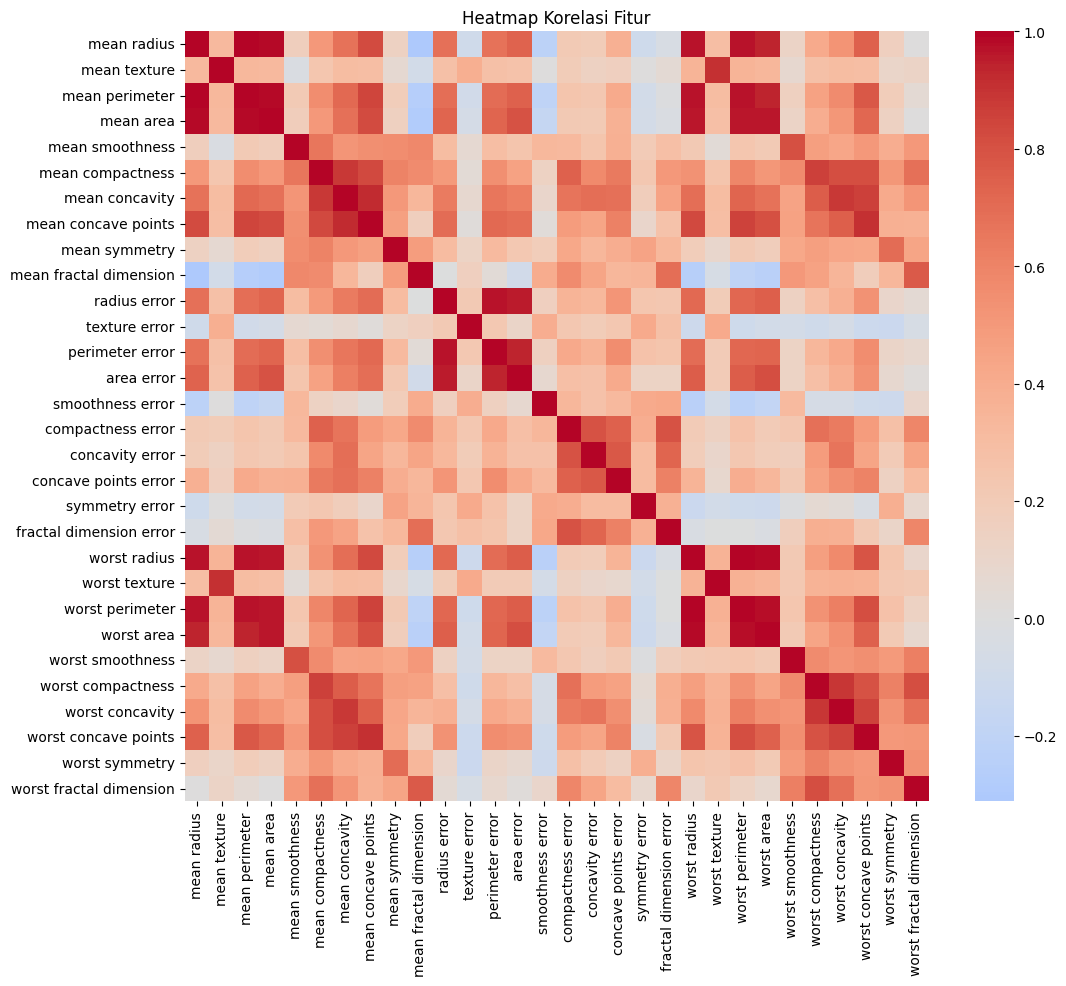

In [14]:
# Korelasi antar fitur
corr_matrix = X.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix,
            cmap='coolwarm',
            center=0)
plt.title("Heatmap Korelasi Fitur")
plt.show()

In [15]:
print(
    corr_matrix["mean radius"]
    .sort_values(ascending=False)
    .head(10)
)

mean radius             1.000000
mean perimeter          0.997855
mean area               0.987357
worst radius            0.969539
worst perimeter         0.965137
worst area              0.941082
mean concave points     0.822529
worst concave points    0.744214
area error              0.735864
radius error            0.679090
Name: mean radius, dtype: float64


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardisasi untuk Logistic Regression
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Data Train :", X_train.shape)
print("Data Test  :", X_test.shape)

Data Train : (455, 30)
Data Test  : (114, 30)


In [17]:
from sklearn.linear_model import LogisticRegression

# Membuat model
log_model = LogisticRegression(max_iter=5000)

# Training
log_model.fit(X_train_s, y_train)

# Prediksi
y_pred_log = log_model.predict(X_test_s)

# Koefisien fitur
coef_df = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": log_model.coef_[0]
})

coef_df = coef_df.sort_values(
    by="Koefisien",
    key=abs,
    ascending=False
)

print("5 Fitur Paling Berpengaruh:")
print(coef_df.head())

5 Fitur Paling Berpengaruh:
                   Fitur  Koefisien
21         worst texture  -1.255088
10          radius error  -1.082965
27  worst concave points  -0.953686
23            worst area  -0.947756
20          worst radius  -0.947616


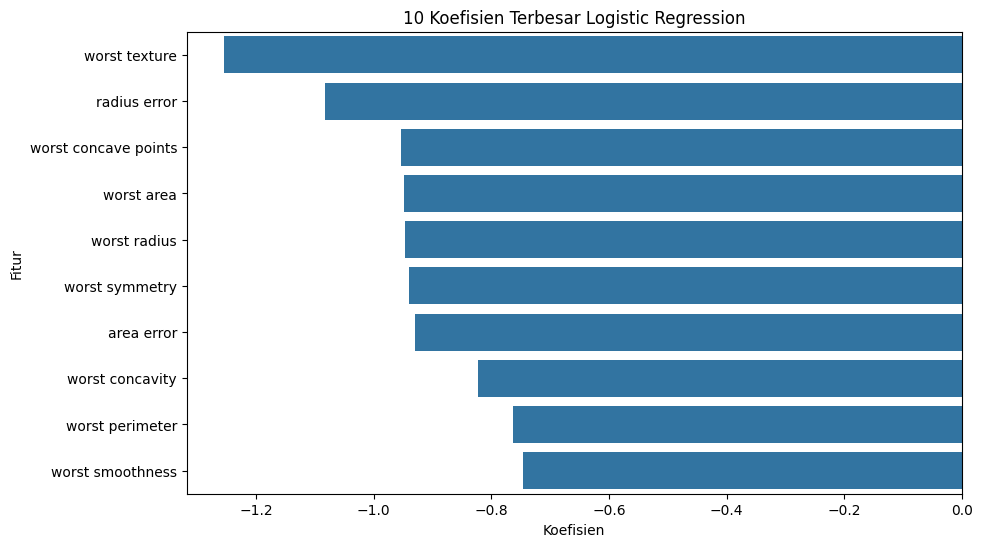

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df.head(10),
    x="Koefisien",
    y="Fitur"
)

plt.title("10 Koefisien Terbesar Logistic Regression")
plt.show()

In [19]:
from sklearn.tree import DecisionTreeClassifier

# Model Decision Tree
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

# Training
tree_model.fit(X_train, y_train)

# Prediksi
y_pred_tree = tree_model.predict(X_test)

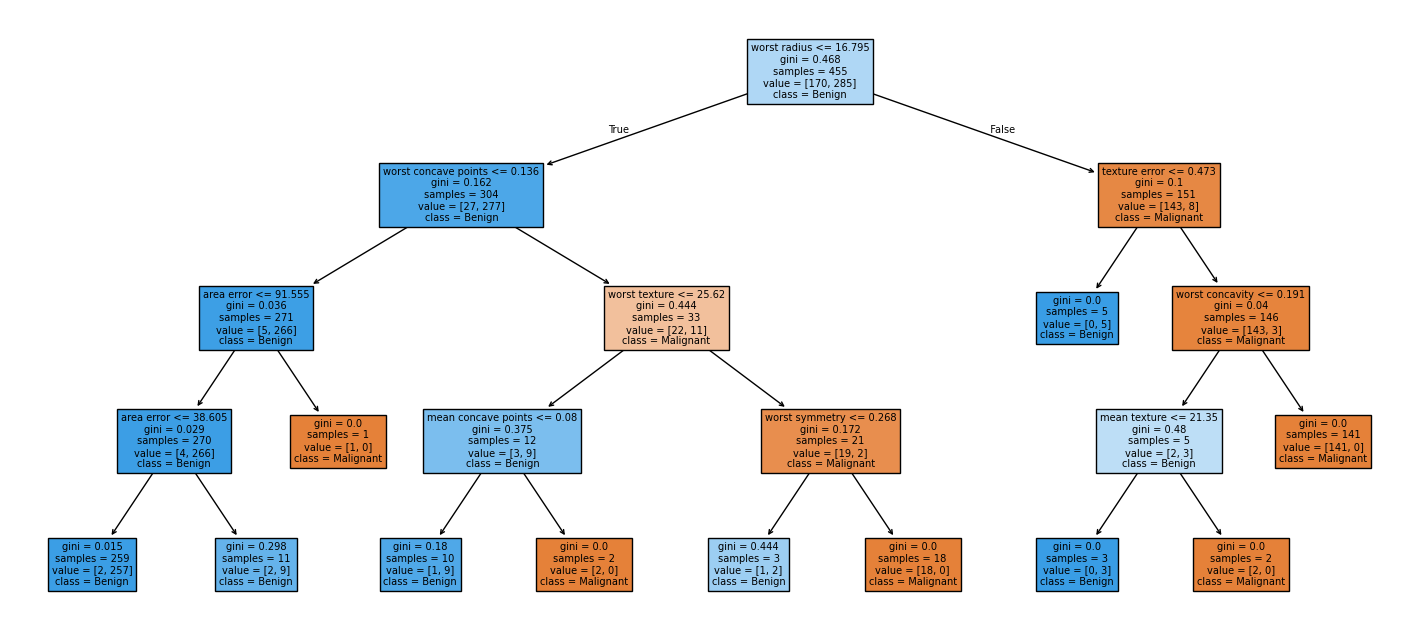

In [20]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=["Malignant", "Benign"],
    filled=True
)

plt.show()

In [21]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(importance_df.head(10))

                 Feature  Importance
20          worst radius    0.733548
27  worst concave points    0.122028
11         texture error    0.045785
21         worst texture    0.032319
26       worst concavity    0.017161
7    mean concave points    0.013327
13            area error    0.012704
1           mean texture    0.011846
28        worst symmetry    0.011282
3              mean area    0.000000


In [22]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

for name, y_pred in [
    ("Logistic Regression", y_pred_log),
    ("Decision Tree", y_pred_tree)
]:

    print(f"\n=== {name} ===")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print(f"Accuracy  : {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision : {precision_score(y_test, y_pred):.3f}")
    print(f"Recall    : {recall_score(y_test, y_pred):.3f}")
    print(f"F1-Score  : {f1_score(y_test, y_pred):.3f}")


=== Logistic Regression ===

Confusion Matrix:
[[41  1]
 [ 1 71]]
Accuracy  : 0.982
Precision : 0.986
Recall    : 0.986
F1-Score  : 0.986

=== Decision Tree ===

Confusion Matrix:
[[39  3]
 [ 4 68]]
Accuracy  : 0.939
Precision : 0.958
Recall    : 0.944
F1-Score  : 0.951


In [23]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111
1,Decision Tree,0.938596,0.957746,0.944444,0.951049


# Analisis Hasil

## Model dengan Recall Lebih Tinggi

Berdasarkan hasil evaluasi, model yang memiliki nilai Recall lebih tinggi dapat dianggap lebih baik dalam mendeteksi kasus positif pada dataset. Recall menunjukkan kemampuan model dalam mengenali data yang memang termasuk ke dalam kelas positif.

Recall dihitung dengan rumus:

Recall = TP / (TP + FN)

Semakin tinggi nilai Recall, semakin sedikit data positif yang gagal terdeteksi oleh model.

## Mengapa Recall Penting pada Diagnosis Kanker?

Dalam kasus diagnosis kanker, kesalahan yang paling perlu dihindari adalah False Negative, yaitu kondisi ketika pasien yang sebenarnya menderita kanker diprediksi tidak memiliki kanker.

Dampak dari False Negative antara lain:

- Pasien tidak mendapatkan penanganan medis yang sesuai.
- Diagnosis dan pengobatan menjadi terlambat.
- Kondisi penyakit dapat berkembang menjadi lebih serius.
- Risiko komplikasi dan kematian dapat meningkat.

Karena alasan tersebut, Recall menjadi metrik yang sangat penting dalam bidang medis. Model yang mampu mendeteksi lebih banyak kasus positif biasanya lebih diutamakan dibandingkan model yang hanya memiliki Accuracy tinggi.

## Perbandingan Logistic Regression dan Decision Tree

### Logistic Regression

Kelebihan:
- Memiliki performa yang cenderung stabil.
- Hasil prediksi dapat dijelaskan melalui nilai koefisien setiap fitur.
- Cocok digunakan untuk klasifikasi biner seperti pada dataset kanker payudara.

Kekurangan:
- Memerlukan proses standardisasi data sebelum pelatihan model.
- Kurang optimal jika hubungan antar fitur sangat kompleks atau non-linear.

### Decision Tree

Kelebihan:
- Tidak memerlukan proses scaling atau standardisasi data.
- Mudah dipahami karena dapat divisualisasikan dalam bentuk pohon keputusan.
- Mampu menangani hubungan non-linear antar fitur.

Kekurangan:
- Lebih rentan mengalami overfitting jika pohon terlalu dalam.
- Performa dapat berubah cukup signifikan tergantung struktur pohon yang terbentuk.

## Kesimpulan

Dari hasil evaluasi yang diperoleh:

- Kedua model mampu melakukan klasifikasi dengan performa yang baik.
- Model dengan nilai Recall lebih tinggi lebih direkomendasikan untuk kasus diagnosis kanker.
- Recall menjadi metrik utama karena berkaitan langsung dengan jumlah kasus kanker yang berhasil terdeteksi.
- Accuracy tetap penting, tetapi tidak cukup untuk menilai kualitas model pada kasus medis.
- Perbedaan performa kedua model dapat dilihat dari nilai Recall, Precision, dan F1-Score yang diperoleh selama pengujian.

Secara keseluruhan, model yang menghasilkan Recall tertinggi lebih layak dipilih karena dapat meminimalkan kemungkinan pasien kanker tidak terdeteksi oleh sistem.